In [ ]:
import sys, torch
print("Python exe:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Python exe: /usr/bin/python3
Torch: 2.9.0+cu126
CUDA: True


In [ ]:
!pip install datasets transformers
!pip install mecab-python3
!pip install unidic
!python -m unidic download
!pip install pandarallel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 41.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for unidic: filename=unidic-1.1.0-py3-none-any.whl size=7403 sha256=c876d63a6b36bb8042698fa2852d0ceb5025726d3980e90fb408faa1bb56a932
  Stored in directory: /root/.cache/pip/wheels/cb/04/a2/659428f84ed1fa7257f8efb544b36043dd37a7c419e8ca711a
Successfully built unidic
  Attempting uninstall: wasabi
    Found existing installation: wasabi 1.1.3
    Uninstalling wasabi-1.1.3:
      Successfully uninstalled wasabi-1.1.3
download url: https://cotonoha-dic.s3-ap-northeast-1.amazonaws.com/unidic-3.1.0.zip
Dictionary version: 3.1.0+2021-08-31
unidic-3.1.0.zip: 100% 526M/526M [00:25<00:00, 20.8MB/s]
Finished download.
Downloaded UniDic v3.1.0+2021-08-31 to /usr/local/lib/python3.12/dist-packages/unidic/dicdir
  Preparing metadata (setup.py) ... done
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16674 sha256=a550b841847b9d9d7d

In [ ]:
from torch import nn
import datasets
import transformers
import torch
import pandas as pd
import os
from google.colab import drive

import time
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
nltk.download('punkt')

from nltk import bleu_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import MeCab
import unidic


# wakati = MeCab.Tagger('-Owakati')

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

torch.manual_seed(1)
random_state = 42

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
#"""
from datasets import load_dataset
#dataset = datasets.load_dataset('wmt14', 'de-en')
# --- Replaced: use a stable EN-JA dataset (OPUS100) instead of Helsinki-NLP/tatoeba_mt ---
# OPUS100 provides 'train'/'validation'/'test' splits with a 'translation' field {'en': ..., 'ja': ...}.
dataset = load_dataset("opus100", "en-ja")

# Use official splits. If 'test' split is unavailable in some mirrors, fall back to 'validation' as test.
train = dataset["train"]
test = dataset["test"] if "test" in dataset else dataset["validation"]

# Build DataFrames with the  columns as: src (JA), tgt (EN)
train_df = pd.DataFrame(train["translation"]).rename(columns={"ja": "src", "en": "tgt"})
test_df  = pd.DataFrame(test["translation"]).rename(columns={"ja": "src", "en": "tgt"})

#train = dataset["train"]["translation"]
#test = dataset["test"]["translation"]

# train_df = pd.DataFrame(train)
# test_df = pd.DataFrame(test)

# train_df.columns = ["tgt", "src"]
# test_df.columns = ["tgt", "src"]

#src_tokenize = lambda text:  " ".join(nltk.tokenize.word_tokenize(text))
#tgt_tokenize = lambda text:  " ".join(nltk.tokenize.word_tokenize(text))
#"""

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-ja/test-00000-of-00001.parquet:   0%|          | 0.00/140k [00:00<?, ?B/s]

en-ja/train-00000-of-00001.parquet:   0%|          | 0.00/64.5M [00:00<?, ?B/s]

en-ja/validation-00000-of-00001.parquet:   0%|          | 0.00/140k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print(train_df.columns)
print(train_df.head(3))

Index(['tgt', 'src'], dtype='object')
                                                 tgt  \
0                               Yeah, Vincent Hanna.   
1  I'm being held in a basement. I've been abduct...   
2                                          It works!   

                          src  
0  - ラウール - ラウールに ヴィンセント・ハンナだ  
1  いま地下に居ます 他の2人と一緒に誘拐されたんです！  
2                       動いたよ！  


In [ ]:
# print("SRC column name:", train_df.src.)  # or just 'src'
print(train_df.src)

0                                - ラウール - ラウールに ヴィンセント・ハンナだ
1                                いま地下に居ます 他の2人と一緒に誘拐されたんです！
2                                                     動いたよ！
3                                              何があったか突き止めたい
4                                                      無事か？
                                ...                        
999995                                                 そうか？
999996                                        ある記憶は すぐ忘れられ、
999997     主は信仰して善行に動む者を（十分に）報奨される。だがアッラーは，不義を行う者を御好みにならない。
999998    またかれは，われに準えるものを引合いに出して，自分の創造を忘れ，言う。「誰が，朽ち果てた骨を...
999999                                                - 何だよ
Name: src, Length: 1000000, dtype: object


In [ ]:
# Ensure NLTK tokenizers are available in all worker processes
try:
    import nltk
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    # Required by newer NLTK versions for sentence tokenization tables
    nltk.download('punkt_tab')

# Do NOT keep a global MeCab.Tagger for multiprocessing; create per call instead.
def src_tokenize(text: str) -> str:
    tagger = MeCab.Tagger('-Owakati')
    out = tagger.parse(text)
    return out.strip() if out is not None else ""

# English: use NLTK word_tokenize (now that punkt/punkt_tab are ensured)
tgt_tokenize = lambda text: " ".join(nltk.tokenize.word_tokenize(text))

# parallel
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)  # workers=1 환경이면 그대로 둬도 됩니다.

MAX_TRAIN = 100000
MAX_TEST  = 2000

src = train_df.src.parallel_apply(src_tokenize)
tgt = train_df.tgt.parallel_apply(tgt_tokenize)
train_df = pd.concat([src, tgt], axis=1)
train_df = train_df.iloc[:MAX_TRAIN].reset_index(drop=True)
train_df.columns = ["src", "tgt"]

src = test_df.src.parallel_apply(src_tokenize)
tgt = test_df.tgt.parallel_apply(tgt_tokenize)
test_df = pd.concat([src, tgt], axis=1)
test_df  = test_df.iloc[:MAX_TEST].reset_index(drop=True)
test_df.columns = ["src", "tgt"]


'''
# parallel
from pandarallel import pandarallel
pandarallel.initialize()

src = train_df.src.parallel_apply(src_tokenize)
tgt = train_df.tgt.parallel_apply(tgt_tokenize)
train_df = pd.concat([src, tgt], axis=1)
train_df.columns = ["src", "tgt"]
print(train_df)

src = test_df.src.parallel_apply(src_tokenize)
tgt = test_df.tgt.parallel_apply(tgt_tokenize)
test_df = pd.concat([src, tgt], axis=1)
test_df.columns = ["src", "tgt"]
'''

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


'\n# parallel\nfrom pandarallel import pandarallel\npandarallel.initialize()\n\nsrc = train_df.src.parallel_apply(src_tokenize)\ntgt = train_df.tgt.parallel_apply(tgt_tokenize)\ntrain_df = pd.concat([src, tgt], axis=1)\ntrain_df.columns = ["src", "tgt"]\nprint(train_df)\n\nsrc = test_df.src.parallel_apply(src_tokenize)\ntgt = test_df.tgt.parallel_apply(tgt_tokenize)\ntest_df = pd.concat([src, tgt], axis=1)\ntest_df.columns = ["src", "tgt"]\n'

In [ ]:
class Vocab(object):
    def __init__(self, word2id={}):
        self.word2id = dict(word2id)
        self.id2word = {v: k for k, v in self.word2id.items()}
    def build_vocab(self, sentences, min_count=1):
        word_counter = {}
        for sentence in sentences:
            for word in sentence.split():
                word_counter[word] = word_counter.get(word, 0) + 1

        for word, count in sorted(word_counter.items(), key=lambda x: -x[1]):
            if count < min_count:
                break
            _id = len(self.word2id)
            self.word2id.setdefault(word, _id)
            self.id2word[_id] = word

In [ ]:
train_X = train_df.src.to_list()
train_Y = train_df.tgt.to_list()

train_X, valid_X, train_Y, valid_Y = train_test_split(train_X, train_Y, test_size=0.2, random_state=random_state)
print(train_X[0:2])
print(train_Y[0:2])

['何 し てる の ？', 'それ と も ここ へ 来る 前 に']
['Hey , what are you doing back here ?', "Or studio apartment if we 're getting real here ."]


In [ ]:
MIN_COUNT = 1
# ===== special tokens =====
PAD = 0
UNK = 1
BOS = 2
EOS = 3

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
BOS_TOKEN = "<S>"
EOS_TOKEN = "</S>"
# ==========================
word2id = {
    PAD_TOKEN: PAD,
    BOS_TOKEN: BOS,
    EOS_TOKEN: EOS,
    UNK_TOKEN: UNK,
    }

vocab_X = Vocab(word2id=word2id)
vocab_Y = Vocab(word2id=word2id)
print(vocab_X.word2id.get(UNK_TOKEN))
print(vocab_Y.word2id[EOS_TOKEN])

vocab_X.build_vocab(train_X, min_count=MIN_COUNT)
vocab_Y.build_vocab(train_Y, min_count=MIN_COUNT)

vocab_size_X = len(vocab_X.id2word)
vocab_size_Y = len(vocab_Y.id2word)
print('vocabX size = ', vocab_size_X)
print('vocabY size = ', vocab_size_Y)


1
3
vocabX size =  31958
vocabY size =  34413


In [ ]:
def sentence_to_ids(vocab, sentence, max_seq_len = 200):
    ids = [vocab.word2id.get(word, UNK) for word in sentence.split()]
    ids = ids[:max_seq_len-2]
    ids = [BOS] + ids + [EOS]
    return ids

In [ ]:
train_X = [sentence_to_ids(vocab_X, sentence) for sentence in train_X]
train_Y = [sentence_to_ids(vocab_Y, sentence) for sentence in train_Y]
valid_X = [sentence_to_ids(vocab_X, sentence) for sentence in valid_X]
valid_Y = [sentence_to_ids(vocab_Y, sentence) for sentence in valid_Y]
print(train_X[0:3])
print(train_Y[0:3])

[[2, 31, 17, 32, 4, 13, 3], [2, 38, 18, 20, 71, 105, 247, 113, 6, 3], [2, 23, 899, 79, 8, 3]]
[[2, 135, 5, 45, 37, 8, 187, 100, 51, 9, 3], [2, 367, 4391, 997, 80, 35, 34, 360, 333, 51, 4, 3], [2, 141, 4, 3]]


In [ ]:
class DataLoader(object):
    def __init__(self, src_insts, tgt_insts, batch_size, shuffle=True):
        self.data = list(zip(src_insts, tgt_insts))
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.start_index = 0
        self.reset()

    def reset(self):
        if self.shuffle:
            self.data = shuffle(self.data, random_state=random_state)
        self.start_index = 0

    def __iter__(self):
        return self

    def __next__(self):

        def preprocess_seqs(seqs):
            # パディング
            max_length = max([len(s) for s in seqs])
            data = [s + [PAD] * (max_length - len(s)) for s in seqs]
            # 単語の位置を表現するベクトルを作成
            positions = [[pos+1 if w != PAD else 0 for pos, w in enumerate(seq)] for seq in data]
            data_tensor = torch.tensor(data, dtype=torch.long, device=device)
            position_tensor = torch.tensor(positions, dtype=torch.long, device=device)
            return data_tensor, position_tensor

        # ポインタが最後まで到達したら初期化する
        if self.start_index >= len(self.data):
            self.reset()
            raise StopIteration()

        # バッチを取得して前処理
        src_seqs, tgt_seqs = zip(*self.data[self.start_index:self.start_index+self.batch_size])
        src_data, src_pos = preprocess_seqs(src_seqs)
        tgt_data, tgt_pos = preprocess_seqs(tgt_seqs)

        self.start_index += self.batch_size

        return (src_data, src_pos), (tgt_data, tgt_pos)

In [ ]:
def position_encoding_init(n_position, d_pos_vec):
    position_enc = np.array([[pos / np.power(10000, 2 * (j // 2) / d_pos_vec) for j in range(d_pos_vec)]if pos != 0 else np.zeros(d_pos_vec) for pos in range(n_position)])

    position_enc[1:, 0::2] = np.sin(position_enc[1:, 0::2])
    position_enc[1:, 1::2] = np.cos(position_enc[1:, 1::2])
    return torch.tensor(position_enc, dtype=torch.float)

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_model, attn_dropout=0.1):
        super(ScaledDotProductAttention, self).__init__()
        self.temper = np.power(d_model, 0.5)
        self.dropout = nn.Dropout(attn_dropout)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, q, k, v, attn_mask):
        attn = torch.bmm(q, k.transpose(1, 2)) / self.temper
        attn.data.masked_fill_(attn_mask, -float('inf'))

        attn = self.softmax(attn)
        attn = self.dropout(attn)
        output = torch.bmm(attn, v)

        return output, attn

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, d_model, d_k, d_v, dropout=0.1):
        super(MultiHeadAttention, self).__init__()

        self.n_head = n_head
        self.d_k = d_k
        self.d_v = d_v

        self.w_qs = nn.Parameter(torch.empty([n_head, d_model, d_k], dtype=torch.float))
        self.w_ks = nn.Parameter(torch.empty([n_head, d_model, d_k], dtype=torch.float))
        self.w_vs = nn.Parameter(torch.empty([n_head, d_model, d_v], dtype=torch.float))

        nn.init.xavier_normal_(self.w_qs)
        nn.init.xavier_normal_(self.w_ks)
        nn.init.xavier_normal_(self.w_vs)

        self.attention = ScaledDotProductAttention(d_model)
        self.layer_norm = nn.LayerNorm(d_model)
        self.proj = nn.Linear(n_head*d_v, d_model)

        nn.init.xavier_normal_(self.proj.weight)
        self.dropout = nn.Dropout(dropout)


    def forward(self, q, k, v, attn_mask=None):
        d_k, d_v = self.d_k, self.d_v
        n_head = self.n_head

        residual = q

        batch_size, len_q, d_model = q.size()
        batch_size, len_k, d_model = k.size()
        batch_size, len_v, d_model = v.size()

        q_s = q.repeat(n_head, 1, 1)
        k_s = k.repeat(n_head, 1, 1)
        v_s = v.repeat(n_head, 1, 1)

        q_s = q_s.view(n_head, -1, d_model)
        k_s = k_s.view(n_head, -1, d_model)
        v_s = v_s.view(n_head, -1, d_model)

        q_s = torch.bmm(q_s, self.w_qs)
        k_s = torch.bmm(k_s, self.w_ks)
        v_s = torch.bmm(v_s, self.w_vs)

        q_s = q_s.view(-1, len_q, d_k)
        k_s = k_s.view(-1, len_k, d_k)
        v_s = v_s.view(-1, len_v, d_v)

        outputs, attns = self.attention(q_s, k_s, v_s, attn_mask=attn_mask.repeat(n_head, 1, 1))

        outputs = torch.split(outputs, batch_size, dim=0)
        outputs = torch.cat(outputs, dim=-1)

        outputs = self.proj(outputs)
        outputs = self.dropout(outputs)
        outputs = self.layer_norm(outputs + residual)

        return outputs, attns

In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_hid, d_inner_hid, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Conv1d(d_hid, d_inner_hid, 1)
        self.w_2 = nn.Conv1d(d_inner_hid, d_hid, 1)
        self.layer_norm = nn.LayerNorm(d_hid)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        output = self.relu(self.w_1(x.transpose(1, 2)))
        output = self.w_2(output).transpose(2, 1)
        output = self.dropout(output)
        return self.layer_norm(output + residual)

In [ ]:
def get_attn_padding_mask(seq_q, seq_k):
    batch_size, len_q = seq_q.size()
    batch_size, len_k = seq_k.size()
    pad_attn_mask = seq_k.data.eq(PAD).unsqueeze(1)
    pad_attn_mask = pad_attn_mask.expand(batch_size, len_q, len_k)
    return pad_attn_mask

def get_attn_subsequent_mask(seq):
    attn_shape = (seq.size(1), seq.size(1))
    subsequent_mask = torch.triu(torch.ones(attn_shape, dtype=torch.uint8, device=device), diagonal=1)
    subsequent_mask = subsequent_mask.repeat(seq.size(0), 1, 1)
    return subsequent_mask

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, d_inner_hid, n_head, d_k, d_v, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.slf_attn = MultiHeadAttention(n_head, d_model, d_k, d_v, dropout=dropout)
        self.pos_ffn = PositionwiseFeedForward(d_model, d_inner_hid, dropout=dropout)

    def forward(self, enc_input, slf_attn_mask=None):
        enc_output, enc_slf_attn = self.slf_attn(enc_input, enc_input, enc_input, attn_mask=slf_attn_mask)
        enc_output = self.pos_ffn(enc_output)
        return enc_output, enc_slf_attn

In [ ]:
class Encoder(nn.Module):
    def __init__(self, n_src_vocab, max_length, n_layers=6, n_head=8, d_k=64, d_v=64, d_word_vec=512, d_model=512, d_inner_hid=1024, dropout=0.1):
        super(Encoder, self).__init__()

        n_position = max_length + 1
        self.max_length = max_length
        self.d_model = d_model

        self.position_enc = nn.Embedding(n_position, d_word_vec, padding_idx=PAD)
        self.position_enc.weight.data = position_encoding_init(n_position, d_word_vec)

        self.src_word_emb = nn.Embedding(n_src_vocab, d_word_vec, padding_idx=PAD)

        self.layer_stack = nn.ModuleList([ EncoderLayer(d_model, d_inner_hid, n_head, d_k, d_v, dropout=dropout) for _ in range(n_layers)])

    def forward(self, src_seq, src_pos):

        #print('in Encoder, src_seq = ', src_seq[0:3])
        #print('in Encoder, src_pos = ', src_pos[0:3])
        #quit()
        enc_input = self.src_word_emb(src_seq)
        enc_input += self.position_enc(src_pos)
        #print('in Encoder, enc_input = ', enc_input[0:3])
        #print('in Encoder with pos enc, enc_input = ', enc_input[0:3])
        #exit()
        enc_slf_attns = []
        enc_output = enc_input
        enc_slf_attn_mask = get_attn_padding_mask(src_seq, src_seq)

        for enc_layer in self.layer_stack:
            enc_output, enc_slf_attn = enc_layer(enc_output, slf_attn_mask=enc_slf_attn_mask)
            enc_slf_attns += [enc_slf_attn]

        return enc_output, enc_slf_attns

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, d_inner_hid, n_head, d_k, d_v, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.slf_attn = MultiHeadAttention(n_head, d_model, d_k, d_v, dropout=dropout)
        self.enc_attn = MultiHeadAttention(n_head, d_model, d_k, d_v, dropout=dropout)
        self.pos_ffn = PositionwiseFeedForward(d_model, d_inner_hid, dropout=dropout)

    def forward(self, dec_input, enc_output, slf_attn_mask=None, dec_enc_attn_mask=None):
        dec_output, dec_slf_attn = self.slf_attn(dec_input, dec_input, dec_input, attn_mask=slf_attn_mask)
        dec_output, dec_enc_attn = self.enc_attn(dec_output, enc_output, enc_output, attn_mask=dec_enc_attn_mask)
        dec_output = self.pos_ffn(dec_output)

        return dec_output, dec_slf_attn, dec_enc_attn

In [ ]:
class Decoder(nn.Module):
    def __init__(
            self, n_tgt_vocab, max_length, n_layers=6, n_head=8, d_k=64, d_v=64,
            d_word_vec=512, d_model=512, d_inner_hid=1024, dropout=0.1):

        super(Decoder, self).__init__()
        n_position = max_length + 1
        self.max_length = max_length
        self.d_model = d_model

        self.position_enc = nn.Embedding(n_position, d_word_vec, padding_idx=PAD)
        self.position_enc.weight.data = position_encoding_init(n_position, d_word_vec)

        self.tgt_word_emb = nn.Embedding(n_tgt_vocab, d_word_vec, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)

        self.layer_stack = nn.ModuleList([DecoderLayer(d_model, d_inner_hid, n_head, d_k, d_v, dropout=dropout) for _ in range(n_layers)])

    def forward(self, tgt_seq, tgt_pos, src_seq, enc_output):
        dec_input = self.tgt_word_emb(tgt_seq)
        dec_input += self.position_enc(tgt_pos)

        dec_slf_attn_pad_mask = get_attn_padding_mask(tgt_seq, tgt_seq)
        dec_slf_attn_sub_mask = get_attn_subsequent_mask(tgt_seq)
        dec_slf_attn_mask = torch.gt(dec_slf_attn_pad_mask + dec_slf_attn_sub_mask, 0)

        dec_enc_attn_pad_mask = get_attn_padding_mask(tgt_seq, src_seq)

        dec_slf_attns, dec_enc_attns = [], []

        dec_output = dec_input

        for dec_layer in self.layer_stack:
            dec_output, dec_slf_attn, dec_enc_attn = dec_layer(
                dec_output, enc_output,
                slf_attn_mask=dec_slf_attn_mask,
                dec_enc_attn_mask=dec_enc_attn_pad_mask)

            dec_slf_attns += [dec_slf_attn]
            dec_enc_attns += [dec_enc_attn]

        return dec_output, dec_slf_attns, dec_enc_attns

In [ ]:
class Transformer(nn.Module):
    def __init__(
            self, n_src_vocab, n_tgt_vocab, max_length, n_layers=6, n_head=8,
            d_word_vec=512, d_model=512, d_inner_hid=1024, d_k=64, d_v=64,
            dropout=0.1, proj_share_weight=True):

        super(Transformer, self).__init__()
        self.encoder = Encoder(
            n_src_vocab, max_length, n_layers=n_layers, n_head=n_head,
            d_word_vec=d_word_vec, d_model=d_model,
            d_inner_hid=d_inner_hid, dropout=dropout)
        self.decoder = Decoder(
            n_tgt_vocab, max_length, n_layers=n_layers, n_head=n_head,
            d_word_vec=d_word_vec, d_model=d_model,
            d_inner_hid=d_inner_hid, dropout=dropout)
        self.tgt_word_proj = nn.Linear(d_model, n_tgt_vocab, bias=False)
        nn.init.xavier_normal_(self.tgt_word_proj.weight)
        self.dropout = nn.Dropout(dropout)

        assert d_model == d_word_vec

        if proj_share_weight:
            assert d_model == d_word_vec
            self.tgt_word_proj.weight = self.decoder.tgt_word_emb.weight

    def get_trainable_parameters(self):
        enc_freezed_param_ids = set(map(id, self.encoder.position_enc.parameters()))
        dec_freezed_param_ids = set(map(id, self.decoder.position_enc.parameters()))
        freezed_param_ids = enc_freezed_param_ids | dec_freezed_param_ids
        return (p for p in self.parameters() if id(p) not in freezed_param_ids)

    def forward(self, src, tgt):
        src_seq, src_pos = src
        tgt_seq, tgt_pos = tgt

        src_seq = src_seq[:, 1:]
        src_pos = src_pos[:, 1:]
        tgt_seq = tgt_seq[:, :-1]
        tgt_pos = tgt_pos[:, :-1]

        enc_output, *_ = self.encoder(src_seq, src_pos)
        dec_output, *_ = self.decoder(tgt_seq, tgt_pos, src_seq, enc_output)
        seq_logit = self.tgt_word_proj(dec_output)

        return seq_logit

# train

In [ ]:
def calc_bleu(refs, hyps):
    refs = [[ref[:ref.index(EOS)]] for ref in refs]
    hyps = [hyp[:hyp.index(EOS)] if EOS in hyp else hyp for hyp in hyps]
    return 100 * bleu_score.corpus_bleu(refs, hyps)

In [ ]:
def compute_loss(batch_X, batch_Y, model, criterion, optimizer=None, is_train=True):
    model.train(is_train)

    with torch.amp.autocast('cuda'):
        pred_Y = model(batch_X, batch_Y)
        gold = batch_Y[0][:, 1:].contiguous()
        loss = criterion(pred_Y.view(-1, pred_Y.size(2)), gold.view(-1))

    if is_train:
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        #loss.backward()
        #optimizer.step()

        scaler.update()

    gold = gold.data.cpu().numpy().tolist()
    pred = pred_Y.max(dim=-1)[1].data.cpu().numpy().tolist()

    return loss.item(), gold, pred

In [ ]:
MAX_LENGTH = 250  #128  #250
batch_size = 16
num_epochs = 30  #500
lr = 0.001
# ckpt_path = 'transformer.pth'
max_length = MAX_LENGTH + 2

In [ ]:
model_args = {
    'n_src_vocab': vocab_size_X,
    'n_tgt_vocab': vocab_size_Y,
    'max_length': max_length,
    'proj_share_weight': True,
    'd_k': 32,
    'd_v': 32,
    'd_model': 128,  #96,  #128
    'd_word_vec': 128,
    'd_inner_hid': 256,
    'n_layers': 3,
    'n_head': 6,  #4
    'dropout': 0.1,
}

In [ ]:
drive.mount('/content/drive')

ckpt_path = "/content/drive/MyDrive/transformer_ja_en.pth"

Mounted at /content/drive


In [ ]:
train_dataloader = DataLoader(train_X, train_Y, batch_size)
valid_dataloader = DataLoader(valid_X, valid_Y, batch_size, shuffle=False)

# Check if a checkpoint already exists
if os.path.exists(ckpt_path):
    print("Checkpoint found. Loading model and skipping training.")

    # For inference / evaluation, DataParallel is not necessary
    model = Transformer(**model_args).to(device)
    state_dict = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    TRAIN_FLAG = False

else:
    print("No checkpoint found. Training from scratch.")

    model = Transformer(**model_args).to(device)

    model = torch.nn.DataParallel(model, device_ids=range(torch.cuda.device_count()))

    optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD, reduction='sum').to(device)

    TRAIN_FLAG = True
'''
import time, contextlib, torch
def benchmark_steps(dataloader, steps=200):
    model.train()
    s0 = time.time()
    n = 0
    for i, batch in enumerate(dataloader):
        if i >= steps: break
        loss, _, _ = compute_loss(*batch, model=model, criterion=criterion, optimizer=optimizer, is_train=True)
        n += 1
    dt = time.time() - s0
    print(f"{n} steps in {dt:.1f}s -> {dt/n:.3f}s/step")
    return dt/n

avg = benchmark_steps(train_dataloader, steps=200)
steps_per_epoch = 2500  # 위 계산값
print(f"~{(avg*steps_per_epoch)/60:.1f} min / epoch (rough)")
'''

Checkpoint found. Loading model and skipping training.


'\nimport time, contextlib, torch\ndef benchmark_steps(dataloader, steps=200):\n    model.train()\n    s0 = time.time()\n    n = 0\n    for i, batch in enumerate(dataloader):\n        if i >= steps: break\n        loss, _, _ = compute_loss(*batch, model=model, criterion=criterion, optimizer=optimizer, is_train=True)\n        n += 1\n    dt = time.time() - s0\n    print(f"{n} steps in {dt:.1f}s -> {dt/n:.3f}s/step")\n    return dt/n\n\navg = benchmark_steps(train_dataloader, steps=200)\nsteps_per_epoch = 2500  # 위 계산값\nprint(f"~{(avg*steps_per_epoch)/60:.1f} min / epoch (rough)")\n'

In [ ]:
if TRAIN_FLAG:

  best_valid_bleu = 0.
  results = []
  scaler = torch.amp.GradScaler('cuda', enabled=True)
  #torch.backends.cudnn.benchmark = True

  for epoch in range(1, num_epochs+1):
      start = time.time()
      train_loss = 0.
      train_refs = []
      train_hyps = []
      valid_loss = 0.
      valid_refs = []
      valid_hyps = []
      # train
      for batch in train_dataloader:
          batch_X, batch_Y = batch
          #print("In running traing..")
          #print('batch_X', batch_X[0:3])
          #print('batch_Y', batch_Y[0:3])
          loss, gold, pred = compute_loss(batch_X, batch_Y, model, criterion, optimizer, is_train=True)
          train_loss += loss
          train_refs += gold
          train_hyps += pred
      # valid
      for batch in valid_dataloader:
          batch_X, batch_Y = batch
          loss, gold, pred = compute_loss(batch_X, batch_Y, model, criterion, is_train=False)
          valid_loss += loss
          valid_refs += gold
          valid_hyps += pred

      scheduler.step()

      train_loss /= len(train_dataloader.data)
      valid_loss /= len(valid_dataloader.data)

      train_bleu = calc_bleu(train_refs, train_hyps)
      valid_bleu = calc_bleu(valid_refs, valid_hyps)

      if valid_bleu > best_valid_bleu:
          ckpt = model.module.state_dict()
          torch.save(ckpt, ckpt_path)
          best_valid_bleu = valid_bleu
          print(f"  New best checkpoint saved (valid BLEU={valid_bleu:.2f})")

      elapsed_time = (time.time()-start) / 60
      print('Epoch {} [{:.1f}min]: train_loss: {:5.2f}  train_bleu: {:2.2f}  valid_loss: {:5.2f}  valid_bleu: {:2.2f}'.format(
              epoch, elapsed_time, train_loss, train_bleu, valid_loss, valid_bleu))
      print('-'*80)
      results.append([epoch, elapsed_time, train_loss, train_bleu, valid_loss, valid_bleu])
  print("Training finished. Best model stored in", ckpt_path)

  # After training, create a clean non-DataParallel model for inference
  model = Transformer(**model_args).to(device)
  state_dict = torch.load(ckpt_path, map_location=device)
  model.load_state_dict(state_dict)
  model.eval()
else:
  print("Training skipped. Model loaded from", ckpt_path)


Training skipped. Model loaded from /content/drive/MyDrive/transformer_ja_en.pth


In [ ]:
def test_this(model, src, max_length=20):
    model.eval()

    src_seq, src_pos = src
    batch_size = src_seq.size(0)
    enc_output, enc_slf_attns = model.encoder(src_seq, src_pos)

    tgt_seq = torch.full([batch_size, 1], BOS, dtype=torch.long, device=device)
    tgt_pos = torch.arange(1, dtype=torch.long, device=device)
    tgt_pos = tgt_pos.unsqueeze(0).repeat(batch_size, 1)

    for t in range(1, max_length+1):
        dec_output, dec_slf_attns, dec_enc_attns = model.decoder(
            tgt_seq, tgt_pos, src_seq, enc_output)
        dec_output = model.tgt_word_proj(dec_output)
        out = dec_output[:, -1, :].max(dim=-1)[1].unsqueeze(1)
        tgt_seq = torch.cat([tgt_seq, out], dim=-1)
        tgt_pos = torch.arange(t+1, dtype=torch.long, device=device)
        tgt_pos = tgt_pos.unsqueeze(0).repeat(batch_size, 1)

    return tgt_seq[:, 1:], enc_slf_attns, dec_slf_attns, dec_enc_attns

In [ ]:
def ids_to_sentence(vocab, ids):
    return [vocab.id2word[_id] for _id in ids]

In [ ]:
def trim_eos(ids):
    if EOS in ids:
        return ids[:ids.index(EOS)]
    else:
        return ids

In [ ]:
def decode_ids_to_text(pred_ids):
    pred_ids = trim_eos(pred_ids)
    words = ids_to_sentence(vocab_Y, pred_ids)
    return " ".join(words)

In [ ]:
def make_src_batch(src_ids):
    """
    src_ids: list of token IDs for one Japanese sentence (already BOS/EOS included)
    returns: (src_seq, src_pos) each of shape [1, seq_len]
    """
    seq = torch.tensor([src_ids], dtype=torch.long, device=device)  # [1, L]
    pos = torch.arange(1, seq.size(1) + 1, dtype=torch.long, device=device)  # [L]
    pos = pos.unsqueeze(0)  # [1, L]
    return seq, pos


In [187]:
def beam_search_decode(model, src, beam_size=5, max_length=40):
    """
    Beam search decoding for a single source sentence.

    src: (src_seq, src_pos) from make_src_batch, shapes [1, L]
    beam_size: how many beams to keep
    max_length: max number of generated tokens (excluding BOS)
    returns: best target ID sequence (list of ints, including EOS but excluding BOS)
    """
    model.eval()
    src_seq, src_pos = src
    batch_size = src_seq.size(0)
    assert batch_size == 1, "Beam search here assumes batch_size = 1"

    # 1) Encode source once
    with torch.no_grad():
        enc_output, _ = model.encoder(src_seq, src_pos)

    # 2) Initialize beam with just BOS
    # Each beam element: (tgt_seq_tensor [1, t], log_prob, finished_flag)
    init_seq = torch.full((1, 1), BOS, dtype=torch.long, device=device)  # [1,1]
    beam = [(init_seq, 0.0, False)]  # log_prob = 0 at start

    for t in range(1, max_length + 1):
        new_beam = []
        all_finished = True

        for seq, score, finished in beam:
            if finished:
                # If already finished (ended with EOS), just carry over
                new_beam.append((seq, score, True))
                continue

            all_finished = False

            # Build position ids for current sequence: 1,2,...,len
            pos = torch.arange(1, seq.size(1) + 1, dtype=torch.long, device=device)
            pos = pos.unsqueeze(0)  # [1, len]

            # 3) Run decoder on current partial sequence
            with torch.no_grad():
                dec_output, _, _ = model.decoder(seq, pos, src_seq, enc_output)
                # Projection to vocab: take last time step
                logits = model.tgt_word_proj(dec_output[:, -1, :])  # [1, vocab]
                log_probs = F.log_softmax(logits, dim=-1).squeeze(0)  # [vocab]

            # 4) Get top-k next tokens for this beam
            topk_log_probs, topk_ids = torch.topk(log_probs, beam_size)

            for k in range(beam_size):
                next_id = topk_ids[k].item()
                next_score = score + topk_log_probs[k].item()

                # Append this token to the sequence
                next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
                next_seq = torch.cat([seq, next_token], dim=1)  # [1, t+1]

                next_finished = (next_id == EOS)
                new_beam.append((next_seq, next_score, next_finished))

        # 5) Keep the best 'beam_size' sequences overall
        new_beam.sort(key=lambda x: x[1], reverse=True)  # sort by log_prob desc
        beam = new_beam[:beam_size]

        # If all beams have finished (hit EOS), we can stop early
        if all_finished:
            break

    # 6) Choose the best sequence in the final beam
    best_seq, best_score, _ = max(beam, key=lambda x: x[1])

    # best_seq shape [1, L]; remove BOS at position 0
    best_ids = best_seq[0].tolist()
    if len(best_ids) > 0 and best_ids[0] == BOS:
        best_ids = best_ids[1:]

    return best_ids  # includes EOS if generated


In [186]:
def beam_search_decode_with_LP(model, src, beam_size=5, max_length=40, alpha=0.0):
    """
    Beam search decoding for a single source sentence.

    src: (src_seq, src_pos) from DataLoader, shapes [1, L]
    beam_size: how many beams to keep
    max_length: max number of generated tokens (excluding BOS)
    alpha: length penalty (0.0 → no penalty, 0.6 is common)
    returns: best target ID sequence (list of ints, including EOS but excluding BOS)
    """
    model.eval()
    src_seq, src_pos = src
    batch_size = src_seq.size(0)
    assert batch_size == 1, "Beam search here assumes batch_size = 1"

    # 1) Encode source once
    with torch.no_grad():
        enc_output, _ = model.encoder(src_seq, src_pos)

    # Each beam element: (tgt_seq_tensor [1, t], log_prob_sum, finished_flag)
    init_seq = torch.full((1, 1), BOS, dtype=torch.long, device=device)  # [1,1]
    beam = [(init_seq, 0.0, False)]

    def length_penalty_fn(length):
        # From Google NMT paper
        if alpha <= 0.0:
            return 1.0
        return ((5.0 + length) ** alpha) / ((5.0 + 1.0) ** alpha)

    for t in range(1, max_length + 1):
        new_beam = []
        all_finished = True

        for seq, logp_sum, finished in beam:
            if finished:
                # Already finished → just carry it over
                new_beam.append((seq, logp_sum, True))
                continue

            all_finished = False

            # Build position ids: 1,2,...,len
            pos = torch.arange(1, seq.size(1) + 1, dtype=torch.long, device=device)
            pos = pos.unsqueeze(0)  # [1, len]

            # 3) Run decoder on current partial sequence
            with torch.no_grad():
                dec_output, _, _ = model.decoder(seq, pos, src_seq, enc_output)
                logits = model.tgt_word_proj(dec_output[:, -1, :])  # [1, vocab]
                log_probs = F.log_softmax(logits, dim=-1).squeeze(0)  # [vocab]

            # 4) Get top-k next tokens for this beam
            topk_log_probs, topk_ids = torch.topk(log_probs, beam_size)

            for k in range(beam_size):
                next_id = topk_ids[k].item()
                next_logp_sum = logp_sum + topk_log_probs[k].item()

                next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
                next_seq = torch.cat([seq, next_token], dim=1)  # [1, t+1]

                next_finished = (next_id == EOS)
                new_beam.append((next_seq, next_logp_sum, next_finished))

        # 5) Keep best 'beam_size' beams **after** applying length penalty
        def scored(item):
            seq, logp_sum, finished = item
            length = seq.size(1) - 1  # exclude BOS
            lp = length_penalty_fn(max(length, 1))
            return logp_sum / lp

        new_beam.sort(key=scored, reverse=True)
        beam = new_beam[:beam_size]

        if all_finished:
            break

    # 6) Choose best sequence after length penalty
    best_seq, best_logp, _ = max(beam, key=scored)
    best_ids = best_seq[0].tolist()
    if len(best_ids) > 0 and best_ids[0] == BOS:
        best_ids = best_ids[1:]  # remove BOS
    return best_ids  # includes EOS if generated


In [185]:
def beam_search_with_attn(model, src, beam_size=5, max_length=40):
    """
    Beam search decoding for a single source sentence,
    and return attentions like test_this.

    Returns:
      best_ids_without_BOS, enc_slf_attns, dec_slf_attns, dec_enc_attns
    """
    model.eval()
    src_seq, src_pos = src  # src_seq: [1, Lsrc], src_pos: [1, Lsrc]

    # ----- 1) Encode source once -----
    with torch.no_grad():
        enc_output, enc_slf_attns = model.encoder(src_seq, src_pos)

    # ----- 2) Initialize beam with BOS -----
    # beam element: (seq_tensor [1, t], log_prob, finished_flag)
    init_seq = torch.full((1, 1), BOS, dtype=torch.long, device=device)  # [1,1]
    beam = [(init_seq, 0.0, False)]

    for t in range(1, max_length + 1):
        new_beam = []
        all_finished = True

        for seq, score, finished in beam:
            if finished:
                # already ended with EOS → keep as is
                new_beam.append((seq, score, True))
                continue

            all_finished = False

            # positions: 1,2,...,len(seq)
            pos = torch.arange(1, seq.size(1) + 1, dtype=torch.long, device=device)
            pos = pos.unsqueeze(0)  # [1, len]

            # ----- 3) Decoder for this partial sequence -----
            with torch.no_grad():
                dec_output, _, _ = model.decoder(seq, pos, src_seq, enc_output)
                logits = model.tgt_word_proj(dec_output[:, -1, :])  # last step
                log_probs = F.log_softmax(logits, dim=-1).squeeze(0)  # [vocab]

            # ----- 4) Top-k next tokens -----
            topk_log_probs, topk_ids = torch.topk(log_probs, beam_size)

            for k in range(beam_size):
                next_id = topk_ids[k].item()
                next_score = score + topk_log_probs[k].item()

                next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
                next_seq = torch.cat([seq, next_token], dim=1)  # [1, t+1]

                next_finished = (next_id == EOS)
                new_beam.append((next_seq, next_score, next_finished))

        # ----- 5) Keep best beam_size sequences -----
        new_beam.sort(key=lambda x: x[1], reverse=True)  # sort by log_prob
        beam = new_beam[:beam_size]

        if all_finished:
            break

    # ----- 6) Pick best sequence from final beam -----
    best_seq, best_score, _ = max(beam, key=lambda x: x[1])   # best_seq: [1, Lbest]

    # Now we run the decoder ONCE on the full best_seq to get attentions
    with torch.no_grad():
        # positions for full best sequence
        pos = torch.arange(1, best_seq.size(1) + 1, dtype=torch.long, device=device)
        pos = pos.unsqueeze(0)  # [1, Lbest]

        dec_output, dec_slf_attns, dec_enc_attns = model.decoder(
            best_seq, pos, src_seq, enc_output
        )

    # Convert best_seq to a python list and strip BOS at index 0
    best_ids = best_seq[0].tolist()
    if len(best_ids) > 0 and best_ids[0] == BOS:
        best_ids = best_ids[1:]   # keep EOS if present

    return best_ids, enc_slf_attns, dec_slf_attns, dec_enc_attns


In [184]:
def beam_search_with_LP_attn(model, src, beam_size=5, max_length=40, alpha=0.0):
    """
    Beam search decoder that ALSO returns attention maps
    matching the behavior of `test_this()`.
    """

    model.eval()

    # Unpack source (Japanese input)
    src_seq, src_pos = src
    batch_size = src_seq.size(0)
    assert batch_size == 1, "Beam search currently supports batch_size=1"

    # ----- 1) ENCODE SOURCE -----
    with torch.no_grad():
        enc_output, enc_slf_attns = model.encoder(src_seq, src_pos)

    # Beam item format:
    # (tgt_seq, log_prob_sum, finished_flag, dec_slf_attn_list, dec_enc_attn_list)

    init_seq = torch.full((1, 1), BOS, dtype=torch.long, device=device)
    beam = [(init_seq, 0.0, False, [], [])]

    # Length penalty
    def length_penalty_fn(length):
        if alpha <= 0.0:
            return 1.0
        return ((5.0 + length) ** alpha) / ((5.0 + 1.0) ** alpha)

    # ----- 2) DECODE STEP BY STEP -----
    for t in range(1, max_length + 1):
        new_beam = []
        all_finished = True

        for seq, logp_sum, finished, attn_slf_list, attn_enc_list in beam:

            if finished:
                new_beam.append((seq, logp_sum, True, attn_slf_list, attn_enc_list))
                continue

            all_finished = False

            # Prepare target positions
            pos = torch.arange(1, seq.size(1) + 1, dtype=torch.long, device=device)
            pos = pos.unsqueeze(0)

            # ----- 3) DECODER FOR CURRENT SEQ -----
            with torch.no_grad():
                dec_output, dec_slf_attns, dec_enc_attns = model.decoder(
                    seq, pos, src_seq, enc_output
                )

                # Take last time-step logits
                logits = model.tgt_word_proj(dec_output[:, -1, :])
                log_probs = F.log_softmax(logits, dim=-1).squeeze(0)

            # ----- 4) SELECT TOP-K NEXT TOKENS -----
            topk_log_probs, topk_ids = torch.topk(log_probs, beam_size)

            for k in range(beam_size):
                next_id = topk_ids[k].item()
                next_logp_sum = logp_sum + topk_log_probs[k].item()

                next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
                next_seq = torch.cat([seq, next_token], dim=1)

                # Copy attention lists and append the current step's attention
                new_slf_list = attn_slf_list + [dec_slf_attns]
                new_enc_list = attn_enc_list + [dec_enc_attns]

                next_finished = (next_id == EOS)

                new_beam.append((next_seq, next_logp_sum, next_finished,
                                 new_slf_list, new_enc_list))

        # ----- 5) RANK BY LENGTH-PENALIZED SCORE -----
        def scored(item):
            seq, logp_sum, finished, _, _ = item
            length = max(seq.size(1) - 1, 1)
            lp = length_penalty_fn(length)
            return logp_sum / lp

        new_beam.sort(key=scored, reverse=True)
        beam = new_beam[:beam_size]

        if all_finished:
            break

    # ----- 6) CHOOSE BEST FINAL SEQUENCE -----
    best_seq, best_logp, _, best_slf_list, best_enc_list = max(beam, key=scored)

    # Convert sequence tensor -> python list
    best_ids = best_seq[0].tolist()
    if best_ids[0] == BOS:
        best_ids = best_ids[1:]

    # Return:
    #   best_ids (translation token IDs)
    #   encoder self-attention maps
    #   decoder self-attention maps (per step)
    #   decoder-encoder attention maps (per step)
    return best_ids, enc_slf_attns, best_slf_list, best_enc_list


In [ ]:
jp_text = "これは本です。"


In [ ]:
# 1) Tokenize and convert to IDs
src_tokens = src_tokenize(jp_text)
print("JP tokens:", src_tokens)

src_ids = sentence_to_ids(vocab_X, src_tokens)  # adds BOS/EOS
src_batch = make_src_batch(src_ids)  # (src_seq, src_pos)


JP tokens: これ は 本 です 。


In [188]:
# Using your existing greedy decoder
preds, enc_slf_attns, dec_slf_attns, dec_enc_attns = test_this(model, src_batch)
greedy_ids = preds[0].cpu().numpy().tolist()
greedy_text = decode_ids_to_text(greedy_ids)
print("Greedy:", greedy_text)


Greedy: This is French is .


In [189]:
beam_ids = beam_search_decode(model, src_batch, beam_size=5, max_length=40)
beam_text = decode_ids_to_text(beam_ids)
print("Beam:", beam_text)


Beam: This is French .


In [190]:
beam_ids = beam_search_decode_with_LP(model, src_batch, beam_size=5, max_length=40, alpha=0.6)
beam_text = decode_ids_to_text(beam_ids)
print("Beam with Length Penalty:", beam_text)

Beam with Length Penalty: This is French .


In [ ]:
test_X = test_df.src.to_list()
test_Y = test_df.tgt.to_list()
test_X = [sentence_to_ids(vocab_X, sentence) for sentence in test_X]
test_Y = [sentence_to_ids(vocab_Y, sentence) for sentence in test_Y]

In [289]:
test_dataloader = DataLoader(
    test_X, test_Y, 1,
    shuffle=False
    )

In [296]:
src, tgt = next(test_dataloader)

src_ids = src[0][0].cpu().numpy()
tgt_ids = tgt[0][0].cpu().numpy()

print('src: {}'.format(' '.join(ids_to_sentence(vocab_X, src_ids[1:-1])).split("</S>")[0]))
print('tgt: {}'.format(' '.join(ids_to_sentence(vocab_Y, tgt_ids[1:-1])).split("</S>")[0]))

preds, enc_slf_attns, dec_slf_attns, dec_enc_attns = test_this(model, src)
pred_ids = preds[0].data.cpu().numpy().tolist()
print('out: {}'.format(' '.join(ids_to_sentence(vocab_Y, trim_eos(pred_ids))).split("</S>")[0]))

src: 彼女 の 成功 で 私 も 同じ 事 を やっ て みよう と いう 気 に なっ た 。
tgt: Her success encouraged me to try the same thing .
out: She was given years ago , she was working .


In [275]:
test_dataloader_beam_attn = DataLoader(test_X, test_Y, batch_size=1, shuffle=False)
src, tgt = next(test_dataloader_beam_attn)          # src = (src_seq, src_pos)

src_ids = src[0][0].cpu().numpy()
tgt_ids = tgt[0][0].cpu().numpy()

print('src: {}'.format(' '.join(ids_to_sentence(vocab_X, src_ids[1:-1])).split("</S>")[0]))
print('tgt: {}'.format(' '.join(ids_to_sentence(vocab_Y, tgt_ids[1:-1])).split("</S>")[0]))

best_ids, b_enc_slf_attns, b_dec_slf_attns, b_dec_enc_attns = beam_search_with_attn(
    model, src, beam_size=5, max_length=40
)
# Convert IDs → words for output
pred_sentence = ' '.join(ids_to_sentence(vocab_Y, trim_eos(best_ids)))
print("Beam output:", pred_sentence)

src: もし そう なっ たら
tgt: If what I 'm saying is true ,
Beam output: Well , that 's why we 're talking .


In [276]:
test_dataloader_beam_with_LP_attn = DataLoader(test_X, test_Y, batch_size=1, shuffle=False)
src, tgt = next(test_dataloader_beam_with_LP_attn)          # src = (src_seq, src_pos)

src_ids = src[0][0].cpu().numpy()
tgt_ids = tgt[0][0].cpu().numpy()

print('src: {}'.format(' '.join(ids_to_sentence(vocab_X, src_ids[1:-1])).split("</S>")[0]))
print('tgt: {}'.format(' '.join(ids_to_sentence(vocab_Y, tgt_ids[1:-1])).split("</S>")[0]))

BP_best_ids, BP_enc_slf_attns, BP_dec_slf_attns, BP_dec_enc_attns = beam_search_with_LP_attn(
    model, src, beam_size=5, max_length=40
)
# Convert IDs → words for output
pred_sentence = ' '.join(ids_to_sentence(vocab_Y, trim_eos(BP_best_ids)))
print("Beam output:", pred_sentence)

src: もし そう なっ たら
tgt: If what I 'm saying is true ,
Beam output: Well , that 's why we 're talking .


In [ ]:
test_dataloader = DataLoader(test_X, test_Y, 128, shuffle=False)
refs_list = []
hyp_list = []

for batch in test_dataloader:
    batch_X, batch_Y = batch
    preds, *_ = test_this(model, batch_X)
    preds = preds.data.cpu().numpy().tolist()
    refs = batch_Y[0].data.cpu().numpy()[:, 1:].tolist()
    refs_list += refs
    hyp_list += preds
bleu = calc_bleu(refs_list, hyp_list)
print(bleu)

1.2278219980859582


In [ ]:
test_dataloader_beam = DataLoader(test_X, test_Y, 1, shuffle=False)
refs_list = []
hyp_list = []

for batch in test_dataloader_beam:
    batch_X, batch_Y = batch
    src_seq, src_pos = batch_X
    tgt_seq, tgt_pos = batch_Y
    # preds, *_ = test_this(model, batch_X)
    best_ids = beam_search_decode(model, (src_seq, src_pos),
                                  beam_size=5, max_length=40)

    # Gold target (skip BOS at index 0)
    ref_ids = tgt_seq[0, 1:].data.cpu().numpy().tolist()
    # refs = batch_Y[0].data.cpu().numpy()[:, 1:].tolist()
    refs_list.append(ref_ids)
    hyp_list.append(best_ids)
bleu = calc_bleu(refs_list, hyp_list)
print(bleu)

1.6660749628307294


In [ ]:
test_dataloader_beam = DataLoader(test_X, test_Y, 1, shuffle=False)
refs_list = []
hyp_list = []

for batch in test_dataloader_beam:
    batch_X, batch_Y = batch
    src_seq, src_pos = batch_X
    tgt_seq, tgt_pos = batch_Y
    # preds, *_ = test_this(model, batch_X)
    best_ids = beam_search_decode_with_LP(model, (src_seq, src_pos),
                                  beam_size=5, max_length=40, alpha=0.6)

    # Gold target (skip BOS at index 0)
    ref_ids = tgt_seq[0, 1:].data.cpu().numpy().tolist()
    # refs = batch_Y[0].data.cpu().numpy()[:, 1:].tolist()
    refs_list.append(ref_ids)
    hyp_list.append(best_ids)
bleu_with_penalty = calc_bleu(refs_list, hyp_list)
print(bleu_with_penalty)

1.7954475531035112


In [305]:
src = src_tokenize(input())
print('src: {}'.format(src))

ids = sentence_to_ids(vocab_X, src)
dl = DataLoader([ids], [ids], 1, shuffle=False)
src, _ = next(dl)
preds, enc_slf_attns, dec_slf_attns, dec_enc_attns = test_this(model, src)
pred_ids = preds[0].data.cpu().numpy().tolist()
out_seq = decode_ids_to_text(pred_ids)
print('out: {}'.format(out_seq))

これは本です。
src: これ は 本 です 。
out: This is French is .


In [303]:
src = src_tokenize(input())
print('src: {}'.format(src))

ids = sentence_to_ids(vocab_X, src)
dl = DataLoader([ids], [ids], 1, shuffle=False)
src, _ = next(dl)
beam_ids = beam_search_decode(model, src, beam_size=5, max_length=40)
beam_text = decode_ids_to_text(beam_ids)
print('out: {}'.format(beam_text))

ほんとうにありがとうございます。
src: ほんとう に ありがとう ござい ます 。
out: Thank you very much .


In [304]:
src = src_tokenize(input())
print('src: {}'.format(src))

ids = sentence_to_ids(vocab_X, src)
dl = DataLoader([ids], [ids], 1, shuffle=False)
src, _ = next(dl)
beam_ids = beam_search_decode_with_LP(model, src, beam_size=5, max_length=40, alpha=0.6)
beam_text = decode_ids_to_text(beam_ids)
print('out: {}'.format(beam_text))

ほんとうにありがとうございます。
src: ほんとう に ありがとう ござい ます 。
out: Thank you very much .


In [182]:
def get_full_attentions(model, src, tgt_ids):
    """
    Given predicted target IDs (WITHOUT BOS), re-run the full decoder once
    so all attention maps come in the same shape as test_this().
    """
    model.eval()
    src_seq, src_pos = src

    with torch.no_grad():
        enc_output, enc_slf_attns = model.encoder(src_seq, src_pos)

        # Build full target sequence: [BOS, token1, token2, ..., EOS?]
        tgt = [BOS] + tgt_ids
        tgt_seq = torch.tensor([tgt], dtype=torch.long, device=device)

        # positions 1..L
        pos = torch.arange(1, tgt_seq.size(1) + 1, dtype=torch.long, device=device).unsqueeze(0)

        dec_output, dec_slf_attns, dec_enc_attns = model.decoder(
            tgt_seq, pos, src_seq, enc_output
        )

    return enc_slf_attns, dec_slf_attns, dec_enc_attns


In [ ]:
best_ids, _, _, _ = beam_search_with_attn(model, src)

b_enc, b_dec_slf, b_dec_enc = get_full_attentions(model, src, best_ids)


In [ ]:
best_ids_lp, _, _, _ = beam_search_with_LP_attn(model, src, alpha=0.6)

lp_enc, lp_dec_slf, lp_dec_enc = get_full_attentions(model, src, best_ids_lp)

# **Attention Heatmaps with Greedy Approach(Improved)**

layer 0


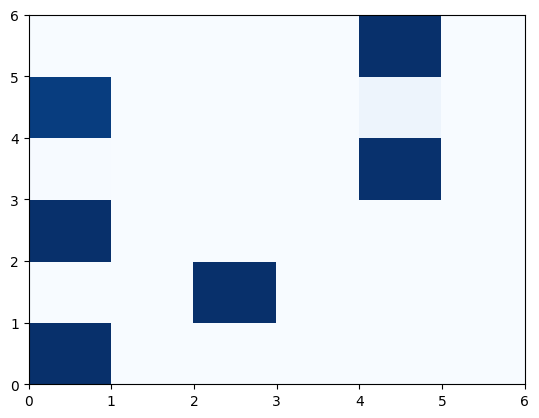

layer 1


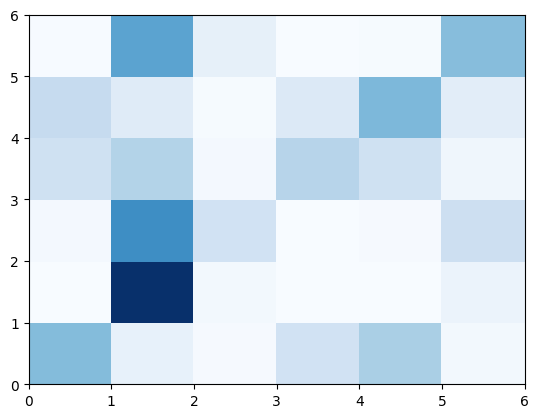

layer 2


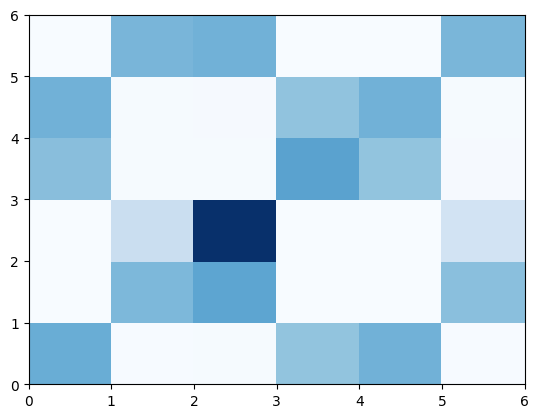

In [175]:
for i in range(len(enc_slf_attns)):
    print("layer {}".format(i))
    plt.pcolor(enc_slf_attns[i][3].cpu().detach().numpy(), cmap=plt.cm.Blues)
    plt.show()

layer 0


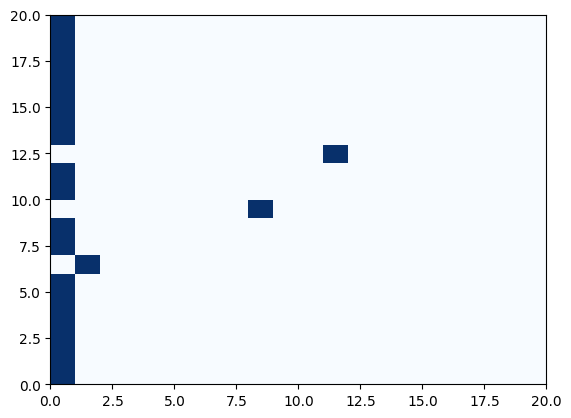

layer 1


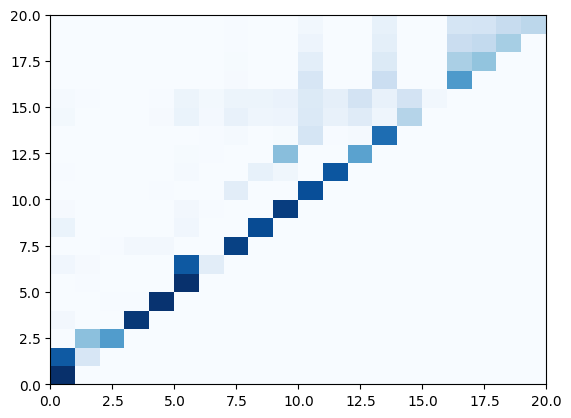

layer 2


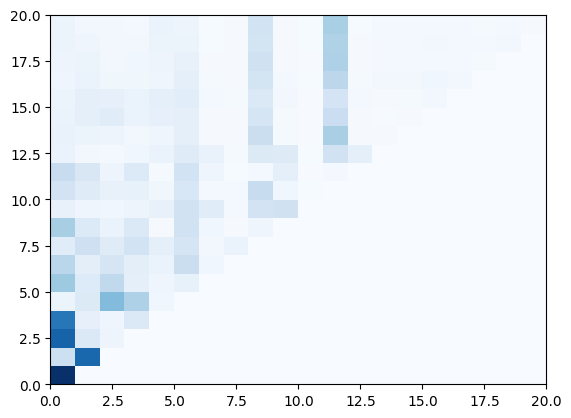

In [176]:
for i in range(len(dec_slf_attns)):
    print("layer {}".format(i))
    plt.pcolor(dec_slf_attns[i][3].cpu().detach().numpy(), cmap=plt.cm.Blues)
    plt.show()

# **Attention Heatmaps with Beam Search**

Encoder layer 0


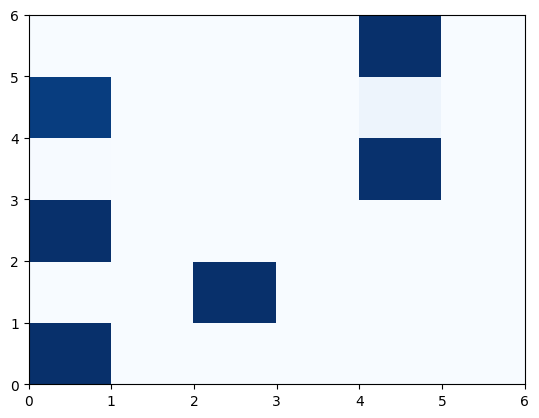

Encoder layer 1


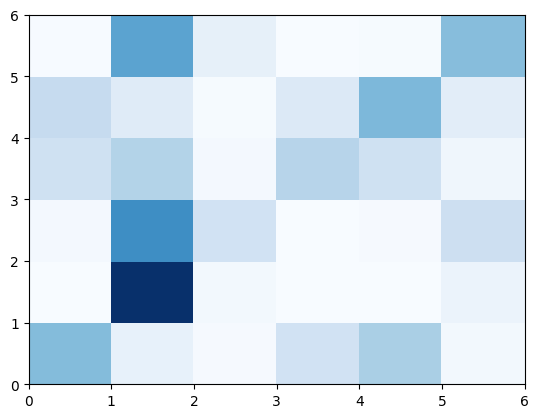

Encoder layer 2


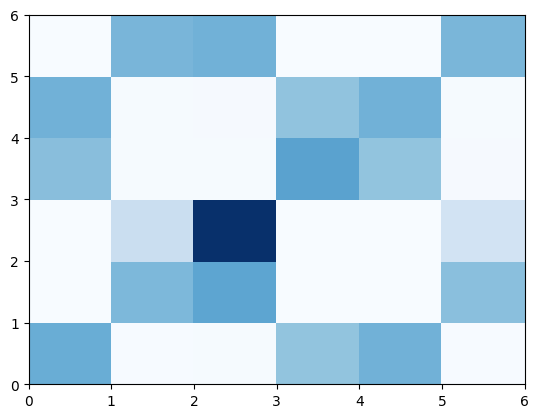

In [177]:
for i in range(len(b_enc)):
    print("Encoder layer", i)
    plt.pcolor(b_enc[i][3].cpu().detach().numpy(), cmap=plt.cm.Blues)
    plt.show()



Decoder layer 0


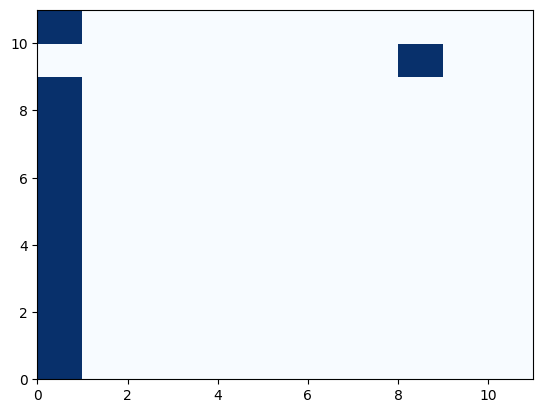

Decoder layer 1


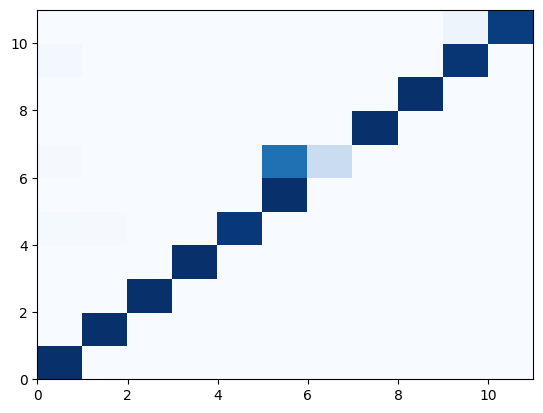

Decoder layer 2


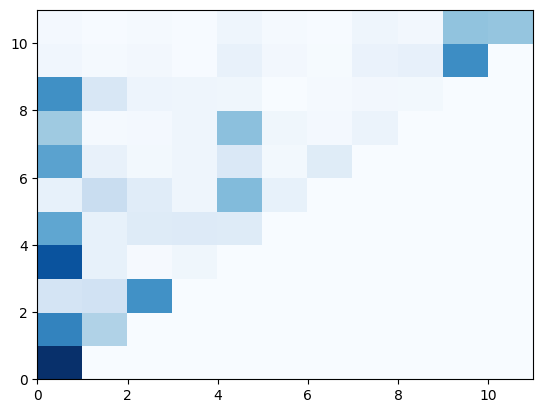

In [178]:
for i in range(len(b_dec_slf)):
    print("Decoder layer {}".format(i))
    plt.pcolor(b_dec_slf[i][3].cpu().detach().numpy(), cmap=plt.cm.Blues)
    plt.show()

# **Attention Heatmaps with Beam Search with Length Penalty**

Encoder layer 0


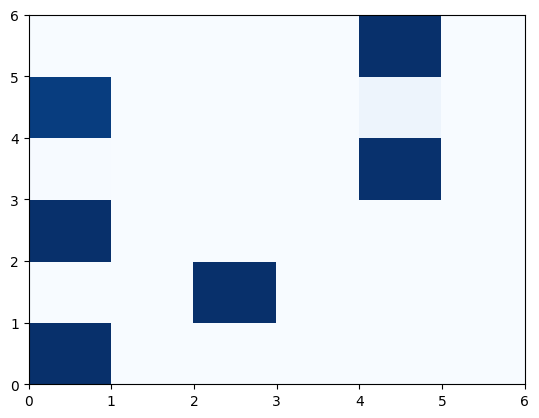

Encoder layer 1


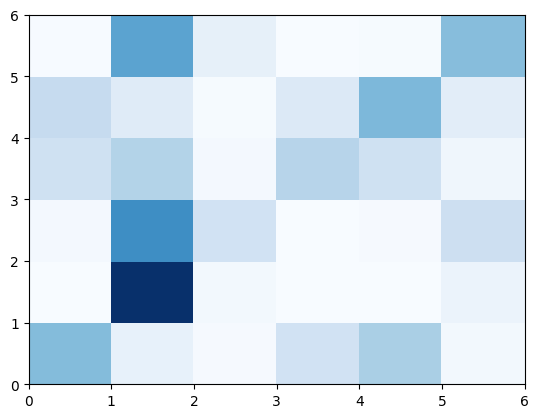

Encoder layer 2


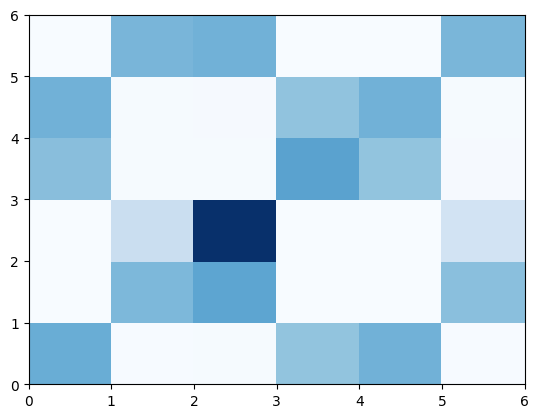

In [179]:
for i in range(len(lp_enc)):
    print("Encoder layer", i)
    plt.pcolor(lp_enc[i][3].cpu().detach().numpy(), cmap=plt.cm.Blues)
    plt.show()


Encoder layer 0


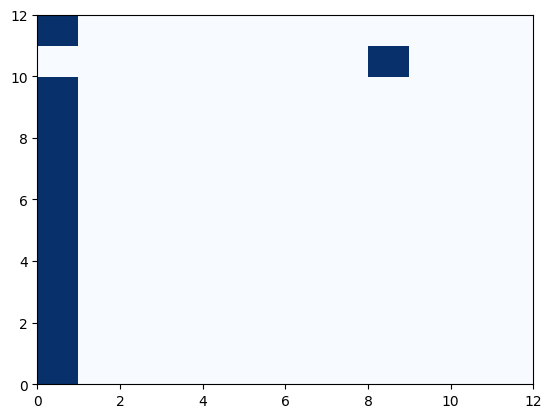

Encoder layer 1


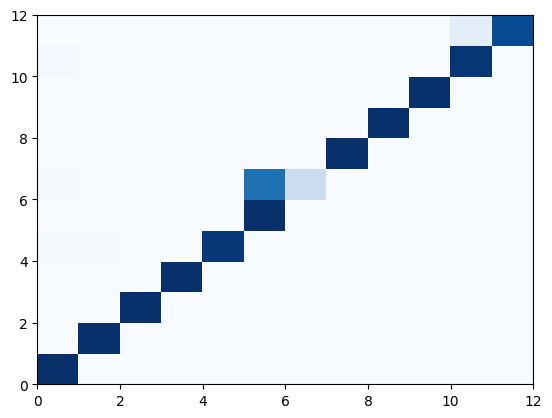

Encoder layer 2


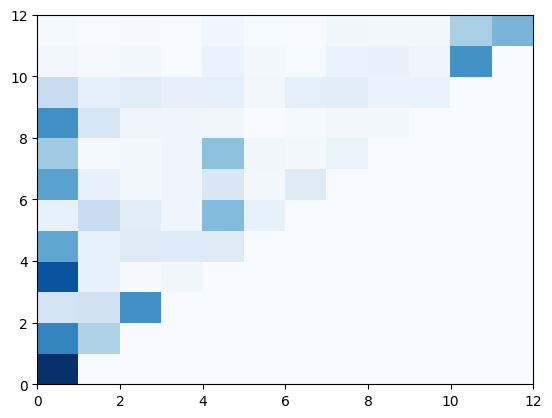

In [180]:
for i in range(len(lp_dec_slf)):
    print("Encoder layer", i)
    plt.pcolor(lp_dec_slf[i][3].cpu().detach().numpy(), cmap=plt.cm.Blues)
    plt.show()


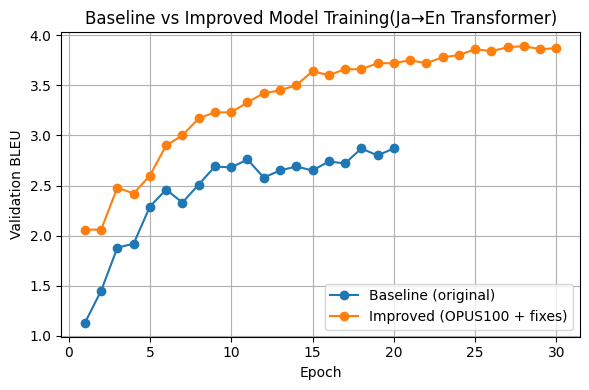

In [306]:
epochs_base = list(range(1, 21))
valid_bleu_base  = [
    1.13, 1.45, 1.88, 1.92, 2.29,
    2.46, 2.33, 2.51, 2.69, 2.68,
    2.76, 2.58, 2.65, 2.69, 2.65,
    2.74, 2.72, 2.87, 2.80, 2.87
]

epochs_impr = list(range(1, 31))
valid_bleu_impr  = [
    2.06,  2.06,  2.48,  2.42,  2.60,  2.90,  3.00,
    3.17,  3.23,  3.23,  3.33,  3.42,  3.45,  3.50,
    3.64,  3.60,  3.66,  3.66,  3.72,  3.72,  3.75,
    3.72,  3.78,  3.80,  3.86,  3.84,  3.88,  3.89,
    3.86,  3.87,
]


plt.figure(figsize=(6,4))
plt.plot(epochs_base, valid_bleu_base, marker='o', label='Baseline (original)')
plt.plot(epochs_impr, valid_bleu_impr, marker='o', label='Improved (OPUS100 + fixes)')
plt.xlabel("Epoch")
plt.ylabel("Validation BLEU")
plt.title("Baseline vs Improved Model Training(Ja→En Transformer)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

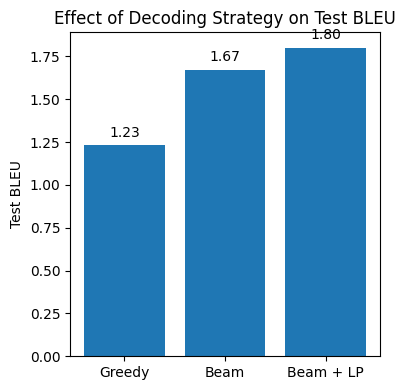

In [193]:
methods = ["Greedy", "Beam", "Beam + LP"]
bleu_scores = [1.23, 1.67, 1.80]  # put your actual values

plt.figure(figsize=(4,4))
plt.bar(methods, bleu_scores)
plt.ylabel("Test BLEU")
plt.title("Effect of Decoding Strategy on Test BLEU")
for i, v in enumerate(bleu_scores):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

**Tiny Dataset Overfitting Test**

In [ ]:


N_TINY = 32     # tiny train size
N_TINY_VAL = 8  # tiny validation size

# Shuffle and take top rows
tiny_df = train_df.sample(N_TINY + N_TINY_VAL, random_state=0).reset_index(drop=True)

tiny_tr_df = tiny_df.iloc[:N_TINY]
tiny_va_df = tiny_df.iloc[N_TINY:N_TINY + N_TINY_VAL]

tiny_train_X = tiny_tr_df["src"].tolist()  # Japanese (tokenized)
tiny_train_Y = tiny_tr_df["tgt"].tolist()  # English (tokenized)

tiny_valid_X = tiny_va_df["src"].tolist()
tiny_valid_Y = tiny_va_df["tgt"].tolist()

print("Tiny train example:")
print("JA:", tiny_train_X[0])
print("EN:", tiny_train_Y[0])


Tiny train example:
JA: ちょうど レイモンドみたいに
EN: Just like raymond.


In [ ]:
#  2. Tiny vocabs and sentence_to_ids

PAD = 0
UNK = 1
BOS = 2
EOS = 3

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
BOS_TOKEN = "<S>"
EOS_TOKEN = "</S>"

base_word2id = {
    PAD_TOKEN: PAD,
    BOS_TOKEN: BOS,
    EOS_TOKEN: EOS,
    UNK_TOKEN: UNK,
}

vocab_X_tiny = Vocab(word2id=base_word2id.copy())  # JA
vocab_Y_tiny = Vocab(word2id=base_word2id.copy())  # EN

MIN_COUNT = 1
vocab_X_tiny.build_vocab(tiny_train_X, min_count=MIN_COUNT)
vocab_Y_tiny.build_vocab(tiny_train_Y, min_count=MIN_COUNT)

vocab_size_X_tiny = len(vocab_X_tiny.id2word)
vocab_size_Y_tiny = len(vocab_Y_tiny.id2word)
print("tiny vocabX size =", vocab_size_X_tiny)
print("tiny vocabY size =", vocab_size_Y_tiny)

def sentence_to_ids_tiny(vocab, sentence, max_seq_len=200):
    ids = [vocab.word2id.get(w, UNK) for w in sentence.split()]
    ids = ids[:max_seq_len - 2]
    ids = [BOS] + ids + [EOS]
    return ids

tiny_train_X_ids = [sentence_to_ids_tiny(vocab_X_tiny, s) for s in tiny_train_X]
tiny_train_Y_ids = [sentence_to_ids_tiny(vocab_Y_tiny, s) for s in tiny_train_Y]
tiny_valid_X_ids = [sentence_to_ids_tiny(vocab_X_tiny, s) for s in tiny_valid_X]
tiny_valid_Y_ids = [sentence_to_ids_tiny(vocab_Y_tiny, s) for s in tiny_valid_Y]

print("Tiny X ids example:", tiny_train_X_ids[0])
print("Tiny Y ids example:", tiny_train_Y_ids[0])

tiny vocabX size = 406
tiny vocabY size = 905
Tiny X ids example: [2, 11, 12, 3]
Tiny Y ids example: [2, 113, 34, 217, 3]


In [ ]:
#3. Tiny DataLoader

BATCH_TINY = 16

tiny_train_dl = DataLoader(tiny_train_X_ids, tiny_train_Y_ids, batch_size=BATCH_TINY, shuffle=True)
tiny_valid_dl = DataLoader(tiny_valid_X_ids, tiny_valid_Y_ids, batch_size=BATCH_TINY, shuffle=False)


In [ ]:
#  Tiny Transformer model and training

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_LENGTH_TINY = 60  # should cover most short sentences

tiny_model_args = {
    'n_src_vocab': vocab_size_X_tiny,
    'n_tgt_vocab': vocab_size_Y_tiny,
    'max_length': MAX_LENGTH_TINY + 2,
    'proj_share_weight': True,
    'd_k': 16,
    'd_v': 16,
    'd_model': 64,
    'd_word_vec': 64,
    'd_inner_hid': 128,
    'n_layers': 1,   # fewer layers for speed
    'n_head': 4,
    'dropout': 0.1,
}

tiny_model = Transformer(**tiny_model_args).to(DEVICE)
# tiny_model = torch.nn.DataParallel(tiny_model, device_ids=range(torch.cuda.device_count()))

tiny_optimizer = optim.Adam(tiny_model.parameters(), lr=0.001)
tiny_criterion = nn.CrossEntropyLoss(ignore_index=PAD, reduction='sum').to(DEVICE)


In [ ]:
def compute_loss_tiny(batch_X, batch_Y, model, criterion, optimizer=None, is_train=True):
    model.train(is_train)

    if is_train:
        optimizer.zero_grad()

    pred_Y = model(batch_X, batch_Y)  # [B, T, vocab]
    gold = batch_Y[0][:, 1:].contiguous()  # shift target

    loss = criterion(pred_Y.view(-1, pred_Y.size(2)), gold.view(-1))

    if is_train:
        loss.backward()
        optimizer.step()

    gold_ids = gold.data.cpu().numpy().tolist()
    pred_ids = pred_Y.max(dim=-1)[1].data.cpu().numpy().tolist()

    return loss.item(), gold_ids, pred_ids


In [ ]:
N_EPOCHS_TINY = 100

for ep in range(1, N_EPOCHS_TINY + 1):
    # ---- train ----
    train_loss = 0.0
    train_refs, train_hyps = [], []
    for batch in tiny_train_dl:
        batch_X, batch_Y = batch
        loss, gold, pred = compute_loss_tiny(batch_X, batch_Y, tiny_model, tiny_criterion, optimizer=tiny_optimizer, is_train=True)
        train_loss += loss
        train_refs += gold
        train_hyps += pred

    # ---- valid ----
    valid_loss = 0.0
    valid_refs, valid_hyps = [], []
    for batch in tiny_valid_dl:
        batch_X, batch_Y = batch
        loss, gold, pred = compute_loss_tiny(batch_X, batch_Y, tiny_model, tiny_criterion, optimizer=None, is_train=False)
        valid_loss += loss
        valid_refs += gold
        valid_hyps += pred

    train_loss /= len(tiny_train_dl.data)
    valid_loss /= len(tiny_valid_dl.data)

    train_bleu = calc_bleu(train_refs, train_hyps)
    valid_bleu = calc_bleu(valid_refs, valid_hyps)

    print(f"[tiny] ep {ep:02d} | train_loss={train_loss:.3f} BLEU={train_bleu:.2f} | valid_loss={valid_loss:.3f} BLEU={valid_bleu:.2f}")


[tiny] ep 01 | train_loss=26.397 BLEU=0.00 | valid_loss=129.986 BLEU=0.00
[tiny] ep 02 | train_loss=26.249 BLEU=0.00 | valid_loss=126.972 BLEU=0.00
[tiny] ep 03 | train_loss=25.815 BLEU=2.89 | valid_loss=127.274 BLEU=0.00
[tiny] ep 04 | train_loss=25.245 BLEU=2.16 | valid_loss=130.081 BLEU=0.00
[tiny] ep 05 | train_loss=25.161 BLEU=2.41 | valid_loss=128.326 BLEU=0.00
[tiny] ep 06 | train_loss=24.621 BLEU=3.00 | valid_loss=125.447 BLEU=0.00
[tiny] ep 07 | train_loss=24.001 BLEU=1.94 | valid_loss=128.850 BLEU=0.00
[tiny] ep 08 | train_loss=23.681 BLEU=3.53 | valid_loss=129.583 BLEU=0.00
[tiny] ep 09 | train_loss=23.600 BLEU=3.82 | valid_loss=133.823 BLEU=0.00
[tiny] ep 10 | train_loss=23.637 BLEU=0.00 | valid_loss=132.093 BLEU=0.00
[tiny] ep 11 | train_loss=22.713 BLEU=2.97 | valid_loss=131.756 BLEU=0.00
[tiny] ep 12 | train_loss=22.227 BLEU=3.23 | valid_loss=136.377 BLEU=0.00
[tiny] ep 13 | train_loss=22.568 BLEU=2.31 | valid_loss=134.145 BLEU=0.00
[tiny] ep 14 | train_loss=21.777 BLEU=

In [ ]:
def ids_to_sentence_tiny(vocab, ids):
    return [vocab.id2word[_id] for _id in ids]

def trim_eos(ids):
    return ids[:ids.index(EOS)] if EOS in ids else ids

# Pick a training example
ex_idx = 0
ex_ja = tiny_train_X[ex_idx]
ex_en = tiny_train_Y[ex_idx]
print("JA tokens:", ex_ja)
print("EN gold :", ex_en)

# Convert JA to ids
ex_ids = sentence_to_ids_tiny(vocab_X_tiny, ex_ja)
dl_example = DataLoader([ex_ids], [ex_ids], batch_size=1, shuffle=False)
src_batch, _ = next(dl_example)

# Use your existing test() with tiny_model
preds, enc_slf_attns, dec_slf_attns, dec_enc_attns = test_this(tiny_model, src_batch)
pred_ids = preds[0].data.cpu().numpy().tolist()

out_tokens = ids_to_sentence_tiny(vocab_Y_tiny, trim_eos(pred_ids))
print("EN pred :", " ".join(out_tokens))

JA tokens: ちょうど レイモンドみたいに
EN gold : Just like raymond.
EN pred : Just like like like like like like


In [ ]:
# Find which id corresponds to "-"
for _id, w in vocab_Y_tiny.id2word.items():
    if w == "-":
        print("'-' token id:", _id)
        break

'-' token id: 9


In [ ]:
pred_ids = preds[0].data.cpu().numpy().tolist()
print("pred_ids:", pred_ids)

pred_ids: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
